# De-Time Quant Trading Column Overview

This notebook introduces the column. The column is designed for quant traders who want to use time-series decomposition as a feature layer rather than a black-box trading rule.

**Data policy:** every market-data notebook downloads real market data at runtime through `yfinance`. No artificial price generator is used. If data cannot be downloaded or validated, the loader raises an error.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd()
while ROOT != ROOT.parent and not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent
for path in [ROOT / "src", ROOT / "examples"]:
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from quant_trading.data import fetch_yahoo_prices, fetch_yahoo_ohlcv, data_audit_report, DEFAULT_UNIVERSES
from quant_trading.features import decompose_one_series, walkforward_decompose, build_feature_table
from quant_trading.signals import (
    trend_pullback_signals,
    residual_mean_reversion_signals,
    turtle_donchian_signals,
    pair_trading_weights,
    cross_sectional_rotation_weights,
    residual_stress_filter,
)
from quant_trading.backtest import backtest_weights, backtest_long_short_signals, summarize_returns

## The decomposition-to-signal idea

De-Time returns `trend`, `season`, and `residual` under a common result contract. In trading terms:

- `trend` controls directional bias;
- `season` or cycle controls timing;
- `residual` controls deviation, pullback, mean reversion, and risk stress;
- reconstruction error helps decide when the decomposition is unreliable.

In [2]:
pd.DataFrame({
    "universe": list(DEFAULT_UNIVERSES.keys()),
    "example_tickers": [", ".join(v[:5]) for v in DEFAULT_UNIVERSES.values()],
    "count": [len(v) for v in DEFAULT_UNIVERSES.values()],
})

,universe,example_tickers,count
0,us_large_cap,"AAPL, MSFT, NVDA, AMZN, META",20
1,us_style_etfs,"SPY, QQQ, IWM, DIA, MTUM",10
2,us_sector_etfs,"XLK, XLF, XLE, XLV, XLY",11
3,korea_large_cap,"005930.KS, 000660.KS, 035420.KS, 035720.KS, 05...",12
4,kosdaq_examples,"247540.KQ, 035900.KQ, 263750.KQ, 196170.KQ, 08...",5
5,crypto_large_cap,"BTC-USD, ETH-USD, SOL-USD, BNB-USD, XRP-USD",7


## Visualization: configured universe coverage

The bar chart makes the tutorial universe breadth visible before any strategy notebook runs.

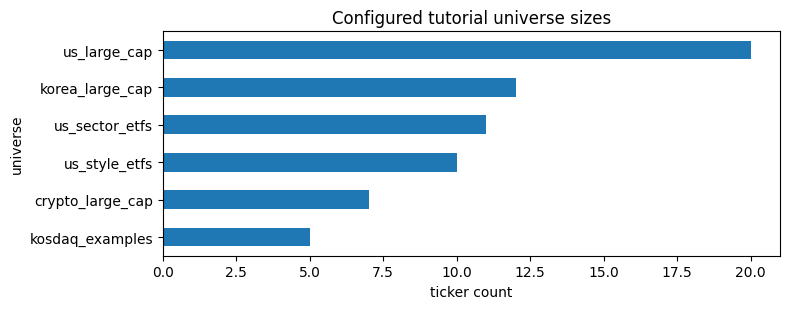

In [3]:
universe_counts = pd.Series(
    {name: len(tickers) for name, tickers in DEFAULT_UNIVERSES.items()},
    name="ticker_count",
).sort_values()
ax = universe_counts.plot(kind="barh", figsize=(8, 3.2), title="Configured tutorial universe sizes")
ax.set_xlabel("ticker count")
ax.set_ylabel("universe")
plt.tight_layout()
plt.show()


## Recommended reading order

1. Real data and De-Time feature factory.
2. Single-asset timing and vectorbt.
3. Turtle/Donchian trend filter.
4. Pairs trading with residual/cycle analysis.
5. Cross-sectional factor selection.
6. Style/sector rotation.
7. Korea, US, and crypto multi-market examples.
8. Backtesting framework adapters.
9. Walk-forward validation and audit.

In [4]:
# Optional dependency installation, run in a shell:
# python -m pip install -e .[dev,docs,notebook]
# python -m pip install -r examples/quant_trading/requirements.txt